<a href="https://colab.research.google.com/github/dindahanifa/mechine_learning/blob/main/Kualitas_Air.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
# =====================================
# 🚀 Percepatan & Pengukuran Eksekusi
# =====================================

# 1️⃣ --- Cek apakah GPU aktif di Colab ---
import os
gpu_info = os.popen('nvidia-smi').read()
if "failed" in gpu_info:
    print("⚠️ GPU belum aktif. Aktifkan via Runtime > Change runtime type > GPU")
else:
    print("✅ GPU aktif dan siap dipakai!")
    print(gpu_info.split('\n')[0])

# 2️⃣ --- Cara 1: Pakai %%time (khusus untuk cell di Colab) ---
# Jalankan ini di satu cell Colab terpisah:
# %%time
# for i in range(10_000_000):
#     _ = i ** 2

# 3️⃣ --- Cara 2: Pakai time.time() manual ---
import time

print("\n⏱️ Mengukur waktu dengan time.time() ...")
start = time.time()
for i in range(10_000_000):
    _ = i ** 2
end = time.time()
print(f"Waktu eksekusi loop biasa: {end - start:.3f} detik")

# 4️⃣ --- Cara 3: Pakai Numba (JIT Compiler) untuk mempercepat Python loop ---
from numba import njit

@njit
def fast_loop(n=10_000_000):
    total = 0
    for i in range(n):
        total += i ** 2
    return total

print("\n⚡ Mengukur waktu dengan Numba (JIT Compilation)...")
start = time.time()
fast_loop()  # pertama kali akan kompilasi (lebih lambat)
end = time.time()
print(f"Pertama kali (kompilasi): {end - start:.3f} detik")

start = time.time()
fast_loop()  # eksekusi berikutnya super cepat
end = time.time()
print(f"Eksekusi berikutnya: {end - start:.3f} detik")

# 5️⃣ --- Cara 4: Gunakan operasi vectorized (NumPy) ---
import numpy as np

print("\n⚙️ Mengukur waktu dengan operasi vectorized NumPy ...")
start = time.time()
x = np.arange(10_000_000)
y = x ** 2  # super cepat tanpa loop manual
end = time.time()
print(f"Waktu eksekusi NumPy: {end - start:.3f} detik")

# 6️⃣ --- Bonus: Decorator otomatis untuk mengukur waktu fungsi ---
def timed(func):
    def wrapper(*args, **kwargs):
        start = time.time()
        result = func(*args, **kwargs)
        end = time.time()
        print(f"⏰ Fungsi '{func.__name__}' selesai dalam {end - start:.3f} detik")
        return result
    return wrapper

@timed
def contoh_fungsi():
    s = 0
    for i in range(5_000_000):
        s += i ** 2
    return s

print("\n🧩 Contoh fungsi dengan decorator otomatis:")
contoh_fungsi()

✅ GPU aktif dan siap dipakai!


⏱️ Mengukur waktu dengan time.time() ...
Waktu eksekusi loop biasa: 1.225 detik

⚡ Mengukur waktu dengan Numba (JIT Compilation)...
Pertama kali (kompilasi): 0.055 detik
Eksekusi berikutnya: 0.000 detik

⚙️ Mengukur waktu dengan operasi vectorized NumPy ...
Waktu eksekusi NumPy: 0.056 detik

🧩 Contoh fungsi dengan decorator otomatis:
⏰ Fungsi 'contoh_fungsi' selesai dalam 0.518 detik


41666654166667500000

**Load Dataset**

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

**Load Dataset**

In [39]:
data = pd.read_excel("//content/WQD.xlsx")
print("Preview data:")
display(data.head())

print("\nInfo kolom:")
print(data.info())

print("\nChecking for missing values:")
print(data.isnull().sum())

print("\nChecking for duplicate rows before dropping:")
print(data.duplicated().sum())

data.drop_duplicates(inplace=True)

print("\nChecking for duplicate rows after dropping:")
print(data.duplicated().sum())

display(data.head())
print("\nNew columns after selection:")
print(data.columns.tolist())

Preview data:


,Temp,Turbidity (cm),DO(mg/L),BOD (mg/L),CO2,pH`,Alkalinity (mg L-1 ),Hardness (mg L-1 ),Calcium (mg L-1 ),Ammonia (mg L-1 ),Nitrite (mg L-1 ),Phosphorus (mg L-1 ),H2S (mg L-1 ),Plankton (No. L-1),Water Quality
0,67.448725,10.127148,0.208153,7.473607,10.181084,4.751657,218.364855,300.125080,337.178226,0.286054,4.355310,0.005984,0.066793,6069.624017,2
1,64.626666,94.015595,11.434463,10.859998,14.860521,3.085154,273.939692,8.426776,363.660740,0.096040,2.182753,0.004906,0.023428,250.995959,2
2,65.121842,90.653462,12.430865,12.809970,12.319980,9.648515,220.812730,11.726274,309.370934,0.974501,4.901760,0.006979,0.065041,7218.927473,2
3,1.640334,0.066344,10.963529,8.508023,12.955209,4.819988,266.571628,6.627655,8.180468,0.884865,3.571842,3.174473,0.026018,1230.062252,2
4,64.863434,2.119173,1.361736,13.335372,13.603197,10.244034,252.108000,339.891514,253.996871,0.801695,4.655898,3.854701,0.060995,1035.054820,2



Info kolom:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4300 entries, 0 to 4299
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temp                  4300 non-null   float64
 1   Turbidity (cm)        4300 non-null   float64
 2   DO(mg/L)              4300 non-null   float64
 3   BOD (mg/L)            4300 non-null   float64
 4   CO2                   4300 non-null   float64
 5   pH`                   4300 non-null   float64
 6   Alkalinity (mg L-1 )  4300 non-null   float64
 7   Hardness (mg L-1 )    4300 non-null   float64
 8   Calcium (mg L-1 )     4300 non-null   float64
 9   Ammonia (mg L-1 )     4300 non-null   float64
 10  Nitrite (mg L-1 )     4300 non-null   float64
 11  Phosphorus (mg L-1 )  4300 non-null   float64
 12  H2S (mg L-1 )         4300 non-null   float64
 13  Plankton (No. L-1)    4300 non-null   float64
 14  Water Quality         4300 non-null   int64  
dtypes: float

,Temp,Turbidity (cm),DO(mg/L),BOD (mg/L),CO2,pH`,Alkalinity (mg L-1 ),Hardness (mg L-1 ),Calcium (mg L-1 ),Ammonia (mg L-1 ),Nitrite (mg L-1 ),Phosphorus (mg L-1 ),H2S (mg L-1 ),Plankton (No. L-1),Water Quality
0,67.448725,10.127148,0.208153,7.473607,10.181084,4.751657,218.364855,300.125080,337.178226,0.286054,4.355310,0.005984,0.066793,6069.624017,2
1,64.626666,94.015595,11.434463,10.859998,14.860521,3.085154,273.939692,8.426776,363.660740,0.096040,2.182753,0.004906,0.023428,250.995959,2
2,65.121842,90.653462,12.430865,12.809970,12.319980,9.648515,220.812730,11.726274,309.370934,0.974501,4.901760,0.006979,0.065041,7218.927473,2
3,1.640334,0.066344,10.963529,8.508023,12.955209,4.819988,266.571628,6.627655,8.180468,0.884865,3.571842,3.174473,0.026018,1230.062252,2
4,64.863434,2.119173,1.361736,13.335372,13.603197,10.244034,252.108000,339.891514,253.996871,0.801695,4.655898,3.854701,0.060995,1035.054820,2



New columns after selection:
['Temp', 'Turbidity (cm)', 'DO(mg/L)', 'BOD (mg/L)', 'CO2', 'pH`', 'Alkalinity (mg L-1 )', 'Hardness (mg L-1 )', 'Calcium (mg L-1 )', 'Ammonia (mg L-1 )', 'Nitrite (mg L-1 )', 'Phosphorus (mg L-1 )', 'H2S (mg L-1 )', 'Plankton (No. L-1)', 'Water Quality']


In [40]:
import pandas as pd

def custom_float_formatter(x):
    if pd.isna(x):
        return None # Menangani nilai NaN

    # Format ke 2 angka desimal
    formatted_2dp = f"{x:.2f}"

    # Cek apakah representasi string 2 angka desimal berakhir dengan '.00'
    if formatted_2dp.endswith('.00'):
        # Jika ya, format ke 3 angka desimal
        return f"{x:.3f}"
    else:
        # Jika tidak, pertahankan 2 angka desimal
        return formatted_2dp

# Identifikasi kolom bertipe float
float_cols = data.select_dtypes(include=['float64']).columns

# Buat dictionary formatter untuk Styler
formatter_dict = {col: custom_float_formatter for col in float_cols}

# Terapkan formatter kustom dan tampilkan DataFrame yang sudah diformat
print("DataFrame dengan format desimal kustom:")
display(data.style.format(formatter_dict))

DataFrame dengan format desimal kustom:


,Temp,Turbidity (cm),DO(mg/L),BOD (mg/L),CO2,pH`,Alkalinity (mg L-1 ),Hardness (mg L-1 ),Calcium (mg L-1 ),Ammonia (mg L-1 ),Nitrite (mg L-1 ),Phosphorus (mg L-1 ),H2S (mg L-1 ),Plankton (No. L-1),Water Quality
0,67.45,10.13,0.21,7.47,10.18,4.75,218.36,300.13,337.18,0.29,4.36,0.01,0.07,6069.62,2
1,64.63,94.02,11.43,10.86,14.86,3.09,273.94,8.43,363.66,0.10,2.18,0.005,0.02,250.996,2
2,65.12,90.65,12.43,12.81,12.32,9.65,220.81,11.73,309.37,0.97,4.90,0.01,0.07,7218.93,2
3,1.64,0.07,10.96,8.51,12.96,4.82,266.57,6.63,8.18,0.88,3.57,3.17,0.03,1230.06,2
4,64.86,2.12,1.36,13.34,13.60,10.24,252.11,339.89,253.997,0.80,4.66,3.85,0.06,1035.05,2
5,3.01,10.47,12.70,12.73,10.06,12.71,279.75,362.55,274.78,0.67,3.47,0.01,0.07,7190.35,2
6,70.60,4.41,14.79,10.12,14.15,10.47,240.20,17.79,265.83,0.17,4.76,4.75,0.10,6690.87,2
7,80.86,96.61,0.72,10.50,13.14,1.49,296.03,16.10,289.47,0.47,2.96,0.002,0.03,416.01,2
8,81.20,11.52,2.21,7.46,14.98,0.05,244.92,7.33,263.26,0.05,2.51,3.22,0.06,7460.42,2
9,1.10,10.59,8.64,14.71,10.28,0.004,269.68,322.39,280.79,0.65,4.64,0.01,0.03,923.11,2


**Correlation Matrix**

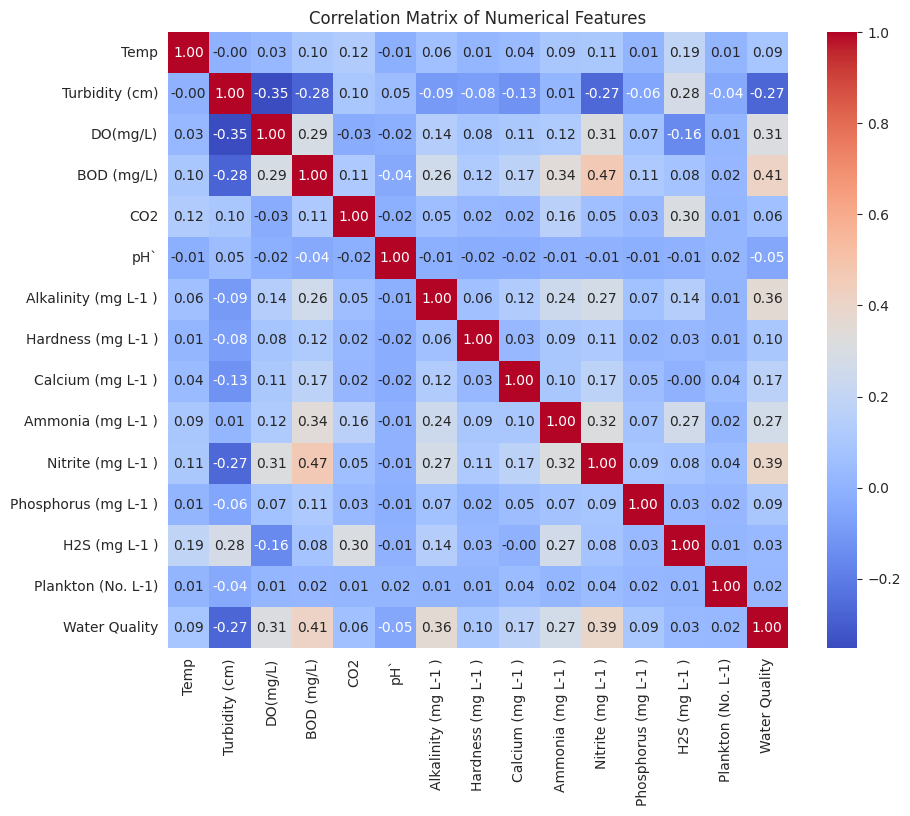

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix for numerical columns
correlation_matrix = data.select_dtypes(include=['number']).corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

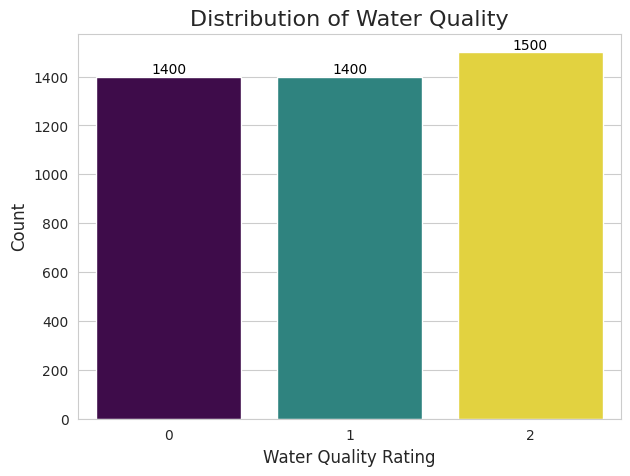

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for the plots
sns.set_style('whitegrid')

# Create a figure and an axes object
plt.figure(figsize=(7, 5))

# Create a count plot for the 'Water Quality' column
sns.countplot(x='Water Quality', data=data, palette='viridis', hue='Water Quality', legend=False)

# Add titles and labels
plt.title('Distribution of Water Quality', fontsize=16)
plt.xlabel('Water Quality Rating', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Add value counts on top of the bars
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                       textcoords='offset points')

plt.show()

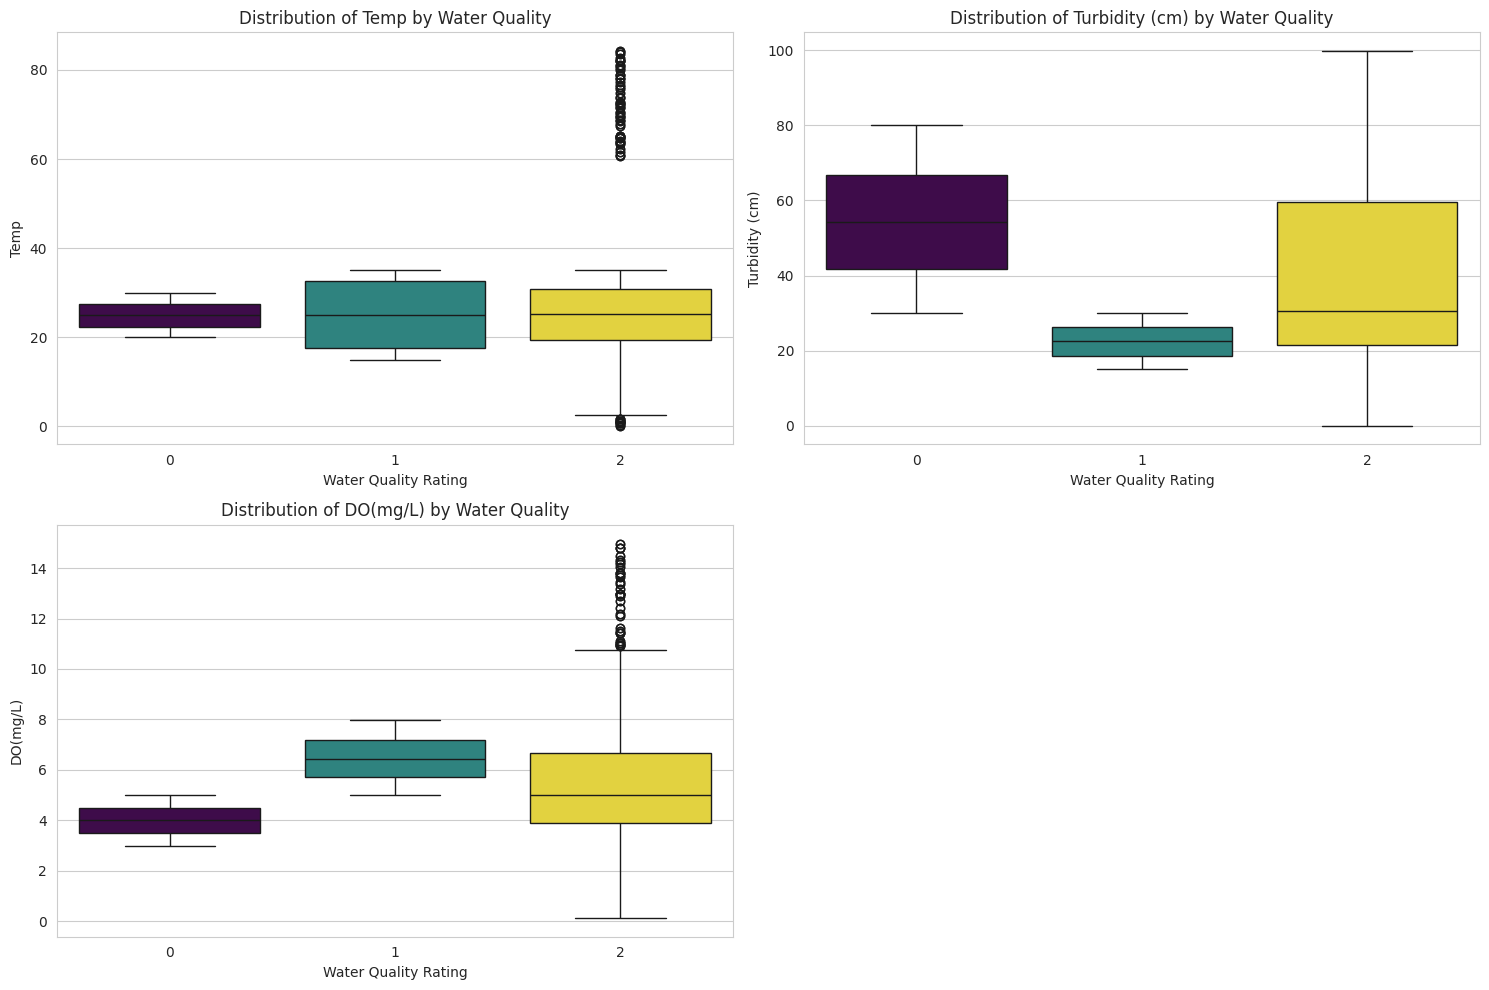

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# Example: plotting some key numerical features against the 'Water Quality' status
relevant_numerical_cols = ['Temp', 'Turbidity (cm)', 'DO(mg/L)'] # Updated to actual columns in your data

# Set up the matplotlib figure and axes for subplots
n_cols = 2  # You can adjust this for more columns if needed
n_rows = (len(relevant_numerical_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 5))
axes = axes.flatten() # Flatten the array of axes for easy iteration

for i, col in enumerate(relevant_numerical_cols):
    sns.boxplot(x='Water Quality', y=col, data=data, ax=axes[i], palette='viridis', hue='Water Quality', legend=False) # Changed 'left' to 'Water Quality'
    axes[i].set_title(f'Distribution of {col} by Water Quality')
    axes[i].set_xlabel('Water Quality Rating')
    axes[i].set_ylabel(col)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Number of rows before dropping NaNs: 4300
Number of rows after dropping NaNs: 4300


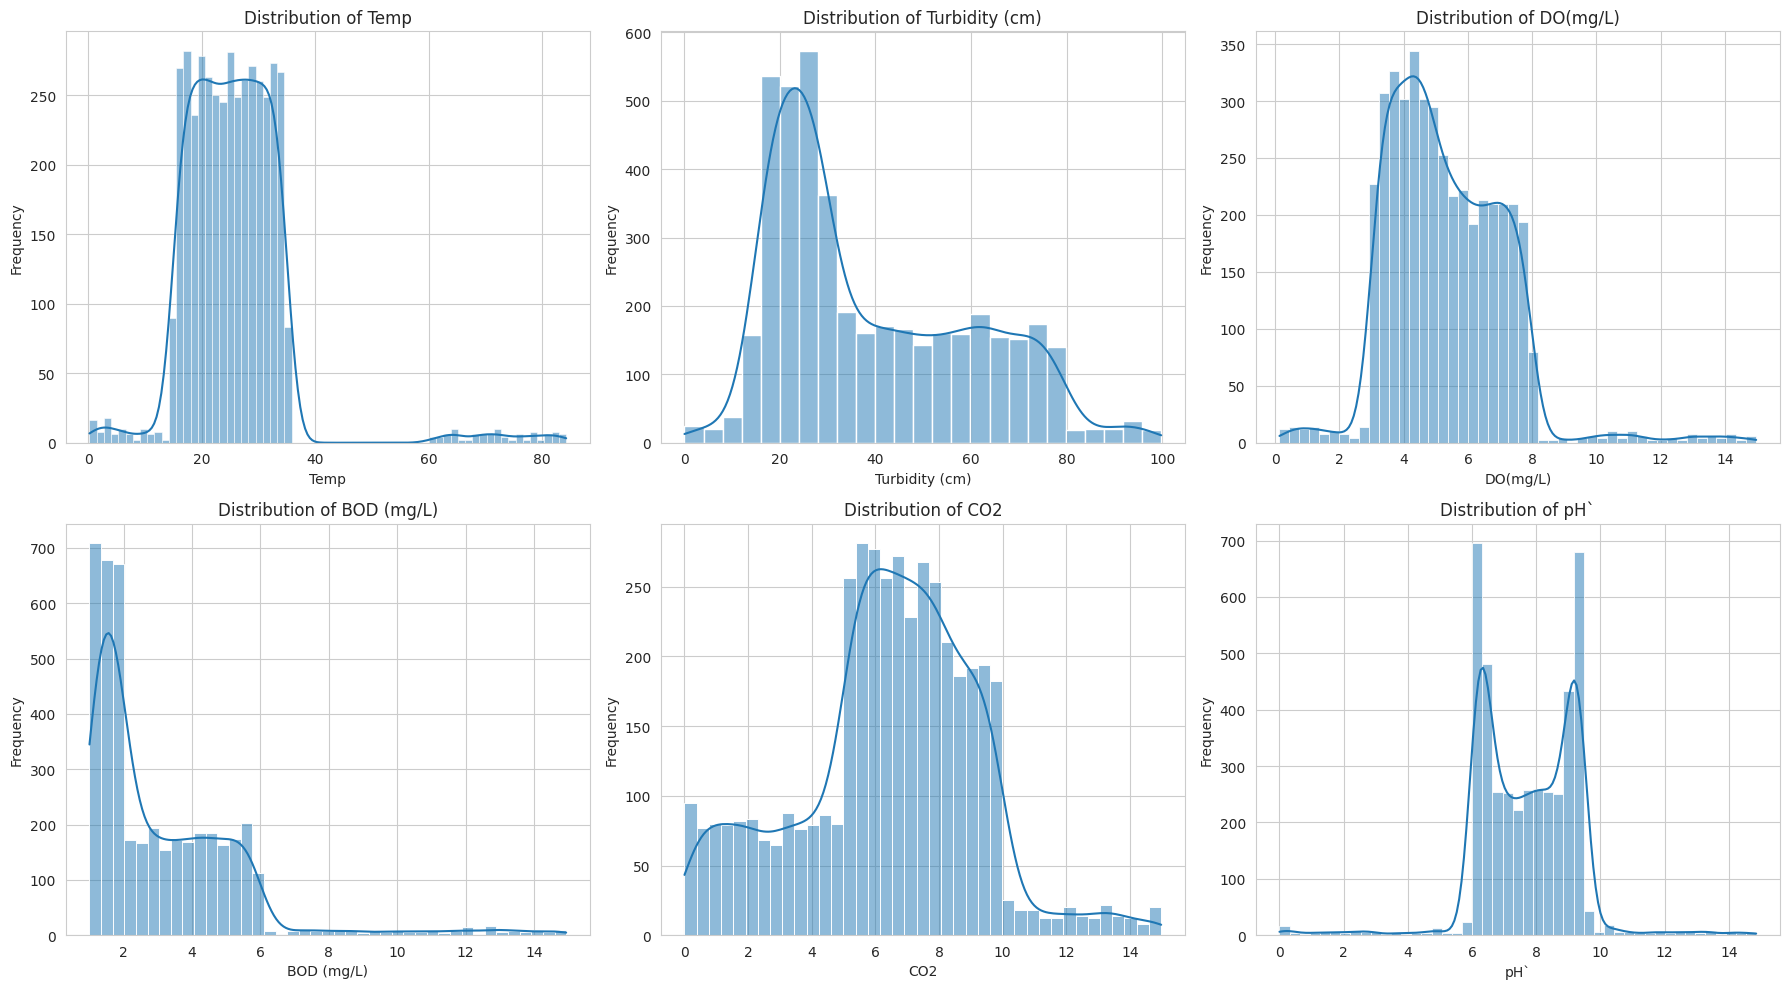


Skewness of numerical features after dropping NaNs:
Temp              2.534656
Turbidity (cm)    0.700381
DO(mg/L)          1.109894
BOD (mg/L)        2.205117
CO2              -0.157483
pH`              -0.380049
dtype: float64


In [44]:
print(f"Number of rows before dropping NaNs: {len(data)}")
data.dropna(inplace=True)
print(f"Number of rows after dropping NaNs: {len(data)}")

# Update numerical_cols_to_plot with actual columns from the water quality dataset
numerical_cols_to_plot = [
    'Temp',
    'Turbidity (cm)',
    'DO(mg/L)',
    'BOD (mg/L)',
    'CO2',
    'pH`' # Using the first 6 relevant numerical columns
]

import matplotlib.pyplot as plt
import seaborn as sns

# Calculate n_rows and n_cols dynamically based on the number of columns to plot
n_cols = 3
n_rows = (len(numerical_cols_to_plot) + n_cols - 1) // n_cols

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(18, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(numerical_cols_to_plot):
    sns.histplot(data[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

print('\nSkewness of numerical features after dropping NaNs:')
print(data[numerical_cols_to_plot].skew())

In [45]:
print("Distribution of 'Water Quality' column:")
print(data['Water Quality'].value_counts())

Distribution of 'Water Quality' column:
Water Quality
2    1500
1    1400
0    1400
Name: count, dtype: int64


In [46]:
# Define features (X) and target (y) based on the current 'data' DataFrame
# 'Water Quality' is the target variable
X = data.drop(['Water Quality'], axis=1) # Drop the target variable to get features
y = data['Water Quality'] # Select 'Water Quality' as the target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split into training and testing sets successfully.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Data split into training and testing sets successfully.
X_train shape: (3440, 14)
X_test shape: (860, 14)
y_train shape: (3440,)
y_test shape: (860,)


In [47]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data standardization completed successfully.")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

Data standardization completed successfully.
X_train_scaled shape: (3440, 14)
X_test_scaled shape: (860, 14)


In [48]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize the Decision Tree model
decision_tree_model = DecisionTreeClassifier(random_state=42)

# Train the model on the scaled training data
decision_tree_model.fit(X_train_scaled, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [66]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize the Decision Tree model with max_depth = 20
decision_tree_model_md20 = DecisionTreeClassifier(max_depth=10, random_state=42)

# Train the model on the scaled training data
decision_tree_model_md20.fit(X_train_scaled, y_train)

print("Decision Tree model with max_depth=20 trained successfully.")

Decision Tree model with max_depth=20 trained successfully.


In [67]:
# Make predictions on the scaled test data
y_pred_md20 = decision_tree_model_md20.predict(X_test_scaled)

# Evaluate the model
accuracy_md20 = accuracy_score(y_test, y_pred_md20)
report_md20 = classification_report(y_test, y_pred_md20)

print(f"Accuracy of Decision Tree model (max_depth=20): {accuracy_md20:.4f}")
print("\nClassification Report for Decision Tree model (max_depth=20):")
print(report_md20)

Accuracy of Decision Tree model (max_depth=20): 0.9849

Classification Report for Decision Tree model (max_depth=20):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       261
           1       0.96      1.00      0.98       274
           2       1.00      0.96      0.98       325

    accuracy                           0.98       860
   macro avg       0.98      0.99      0.99       860
weighted avg       0.99      0.98      0.98       860



In [68]:
results_df = X_test.head(20).copy()
results_df['Actual Categori'] = y_test.head(20)
results_df['Predicted Categori'] = y_pred_dt[:20] # Fixed: Changed y_pred to y_pred_dt

print("Comparison of Actual vs. Predicted Categories (First 20 Test Samples):")
print(results_df[['Actual Categori', 'Predicted Categori']])

Comparison of Actual vs. Predicted Categories (First 20 Test Samples):
      Actual Categori  Predicted Categori
1760                1                   1
3035                0                   0
1921                1                   1
1188                2                   2
109                 2                   2
2570                1                   1
4041                0                   0
511                 2                   2
949                 2                   2
3771                0                   0
3241                0                   0
2864                1                   1
1397                2                   2
3250                0                   0
497                 2                   2
1003                2                   2
2405                1                   1
879                 2                   2
149                 2                   2
3940                0                   0



Accuracy: 0.9849
Precision: 0.9855
Recall: 0.9849
F1 Score: 0.9849

Confusion Matrix:
[[261   0   0]
 [  0 274   0]
 [  1  12 312]]


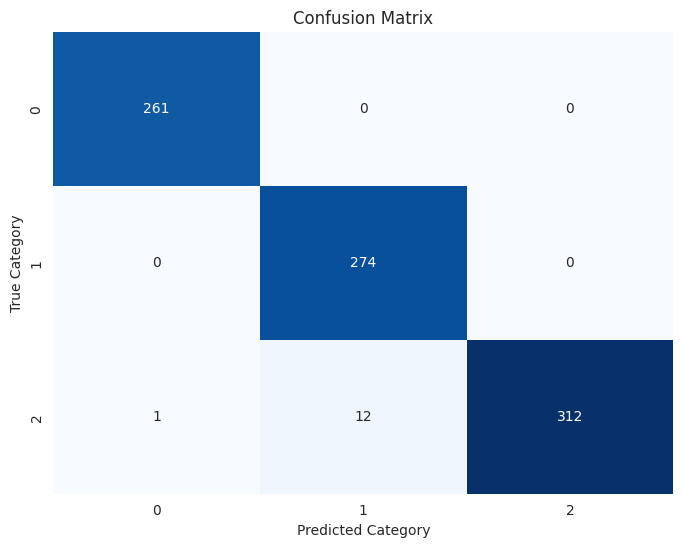

In [70]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Make predictions on the scaled test data using the correctly named model
y_pred_classified = decision_tree_model_md20.predict(X_test_scaled)

# Calculate and print evaluation metrics
accuracy = accuracy_score(y_test, y_pred_classified)
precision = precision_score(y_test, y_pred_classified, average='weighted')
recall = recall_score(y_test, y_pred_classified, average='weighted')
f1 = f1_score(y_test, y_pred_classified, average='weighted')

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Create and print the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_classified)
print("\nConfusion Matrix:")
print(conf_matrix)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Category')
plt.ylabel('True Category')
plt.show()

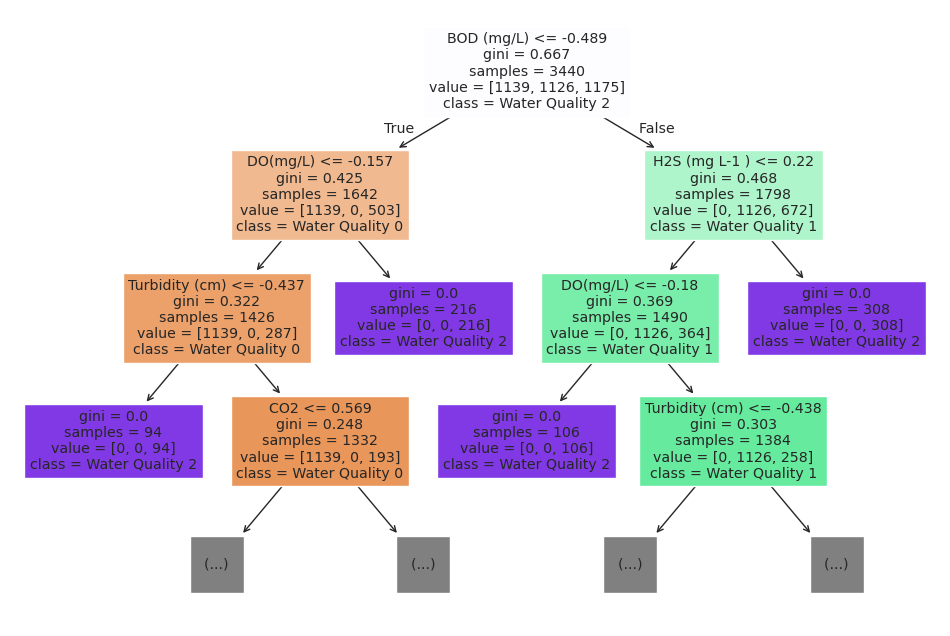

In [72]:
from sklearn import tree
import matplotlib.pyplot as plt

# Use the trained Decision Tree Classifier model (decision_tree_model_md20)
# Use the features used for training (X_train)
# Use the classes from the training target (y_train)

plt.figure(figsize=(12,8))

# Get the unique class labels from the training target
unique_classes = sorted(y_train.unique())

# Define meaningful class names based on the target variable 'Water Quality' (0, 1, 2)
# Assuming 0: Bad, 1: Medium, 2: Good. Adjust if you have specific labels.
class_names_list = ['Water Quality 0', 'Water Quality 1', 'Water Quality 2']

tree.plot_tree(decision_tree_model_md20, filled=True, feature_names=X_train.columns.tolist(), class_names=class_names_list, max_depth=3)
plt.show()

Feature Importances (sorted):
BOD (mg/L)              0.369370
DO(mg/L)                0.196050
H2S (mg L-1 )           0.131826
Turbidity (cm)          0.126788
CO2                     0.072049
Temp                    0.050923
Alkalinity (mg L-1 )    0.027811
Nitrite (mg L-1 )       0.025183
pH`                     0.000000
Hardness (mg L-1 )      0.000000
Ammonia (mg L-1 )       0.000000
Calcium (mg L-1 )       0.000000
Phosphorus (mg L-1 )    0.000000
Plankton (No. L-1)      0.000000
dtype: float64


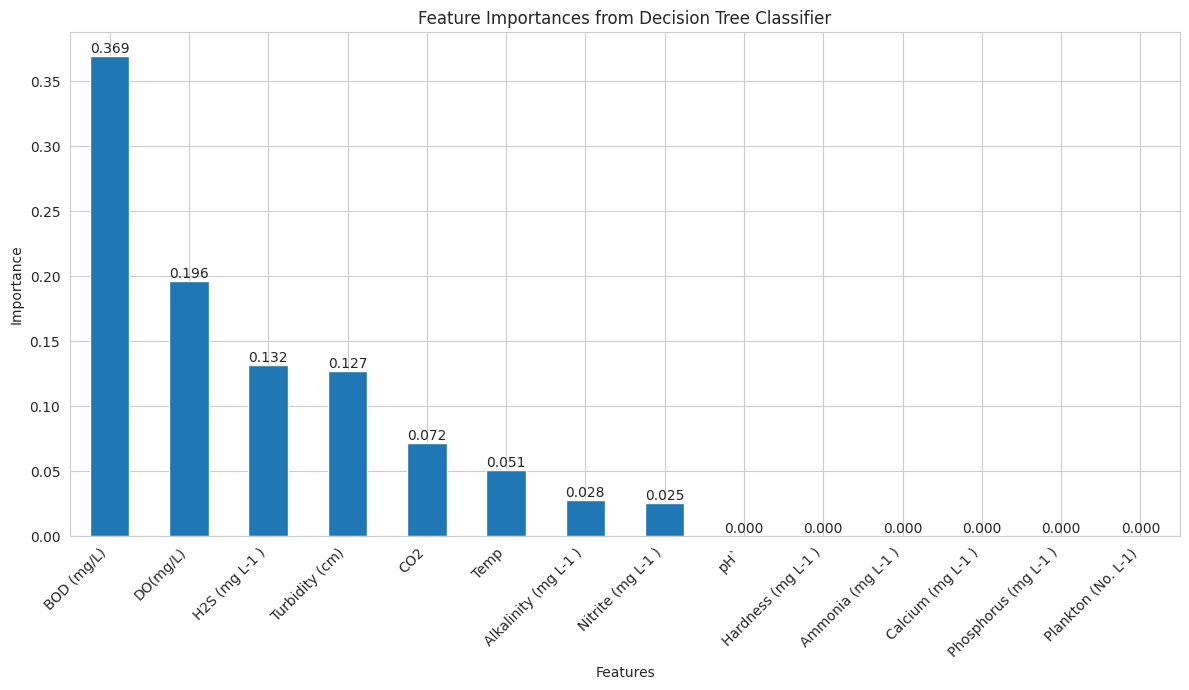

In [74]:

# Get feature importances from the trained model
feature_importances = decision_tree_model_md20.feature_importances_

# Create a pandas Series for better visualization
feature_importance_series = pd.Series(feature_importances, index=X_train.columns)

# Sort the features by importance in descending order
sorted_feature_importances = feature_importance_series.sort_values(ascending=False)

print("Feature Importances (sorted):")
print(sorted_feature_importances)

# Optional: Visualize feature importances
plt.figure(figsize=(12, 7)) # Increased figure size slightly for better readability
ax = sorted_feature_importances.plot(kind='bar')
plt.title('Feature Importances from Decision Tree Classifier')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Add labels on top of the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f') # Format the labels to 3 decimal places

plt.show()